In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import smarts_cerebellum.globals as gl

In [2]:
atlas = 'Nettekoven2024'
rois  = gl.rois[atlas]
colours = ['green', 'r', 'blue']

In [3]:
segment = 'GM'

# observed means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_Nettekoven_2024_{segment}_mod_mean.tsv'), sep = '\t')

# estimated means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_Nettekoven_2024_lme.tsv'), sep = '\t')


# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str.lower().str[2]
controls_lme['hemisphere'] = controls_lme.regionname.str.lower().str[2]
patients_actual['hemisphere'] = patients_actual.regionname.str.lower().str[2]
controls_actual['hemisphere'] = controls_actual.regionname.str.lower().str[2]

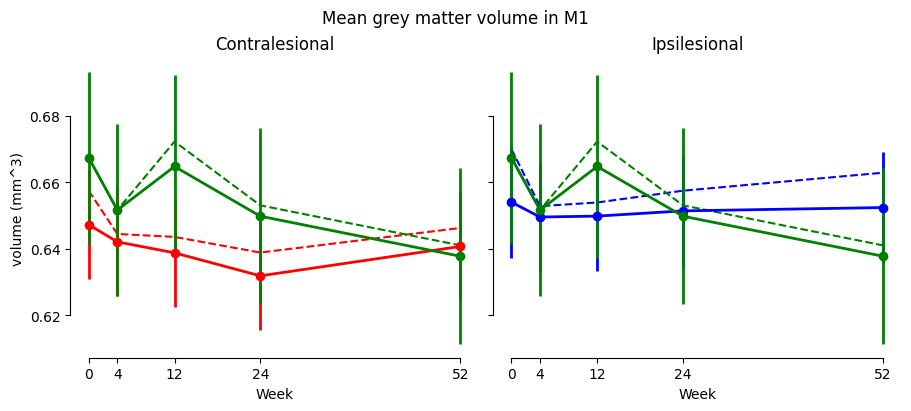

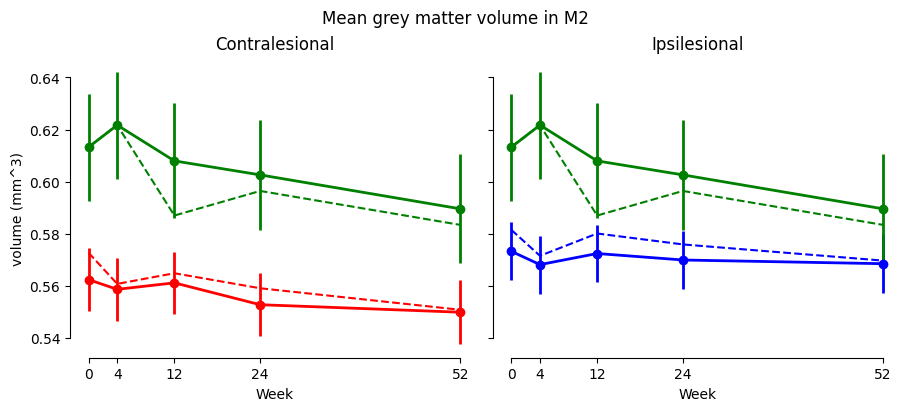

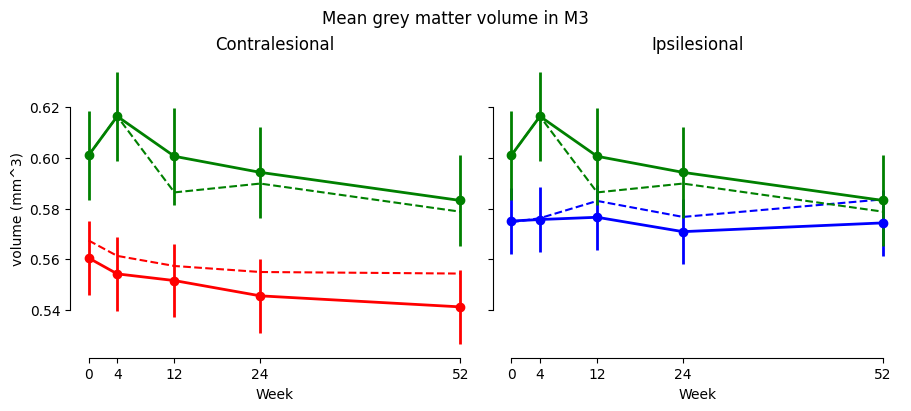

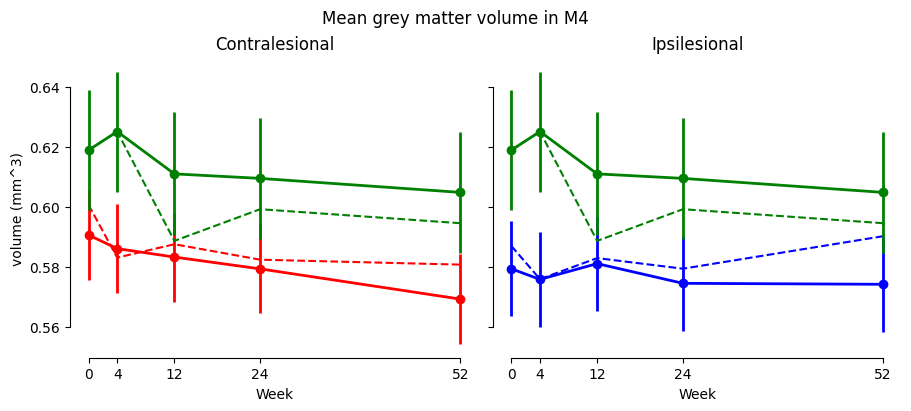

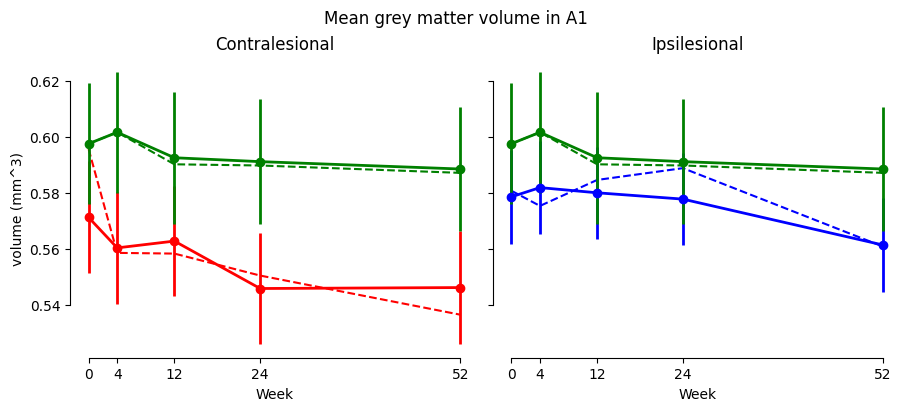

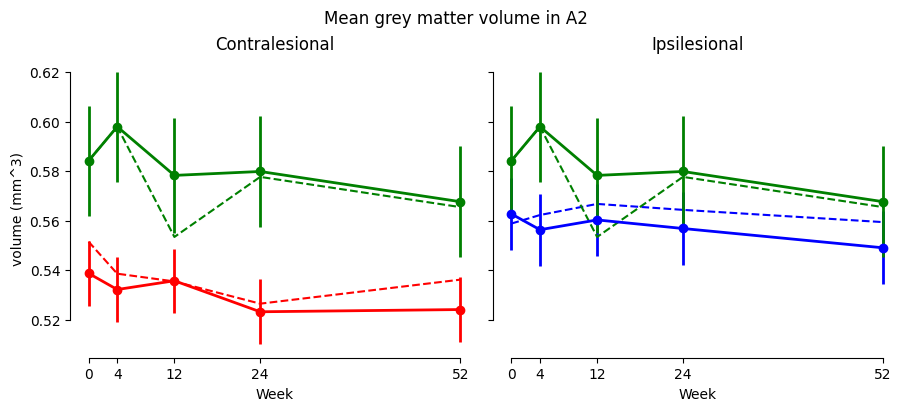

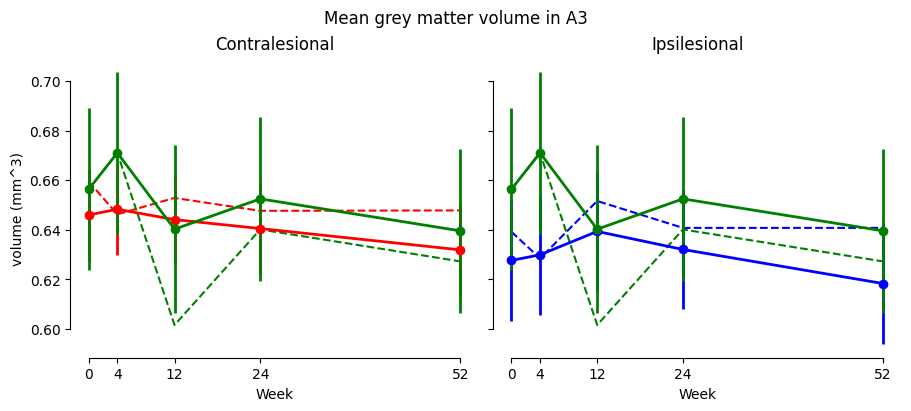

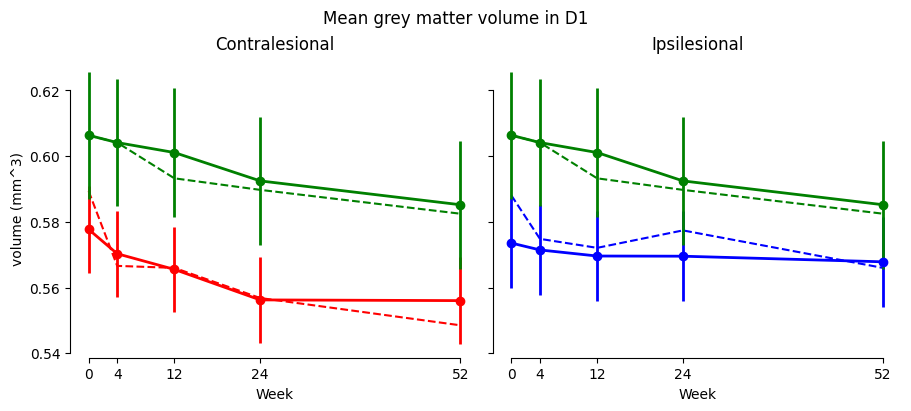

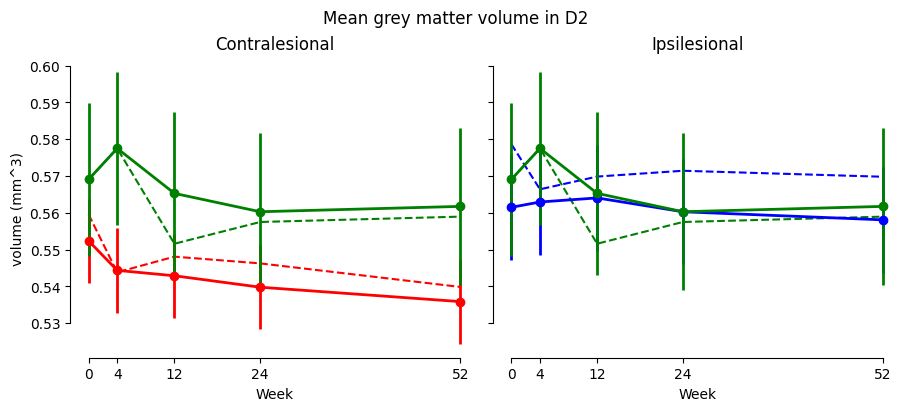

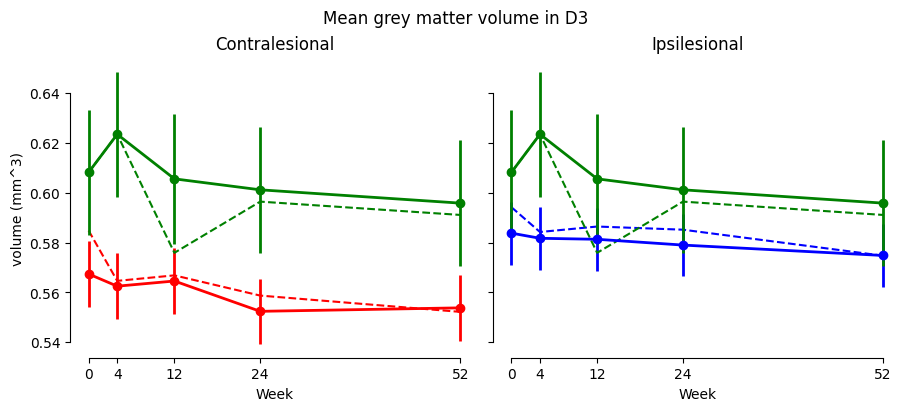

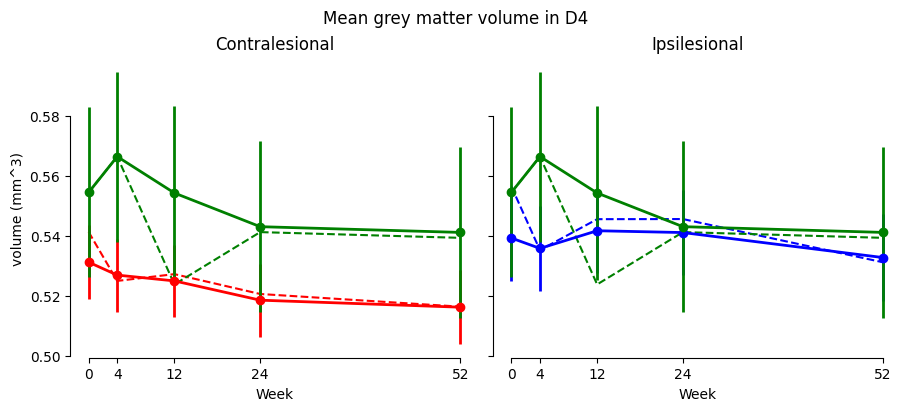

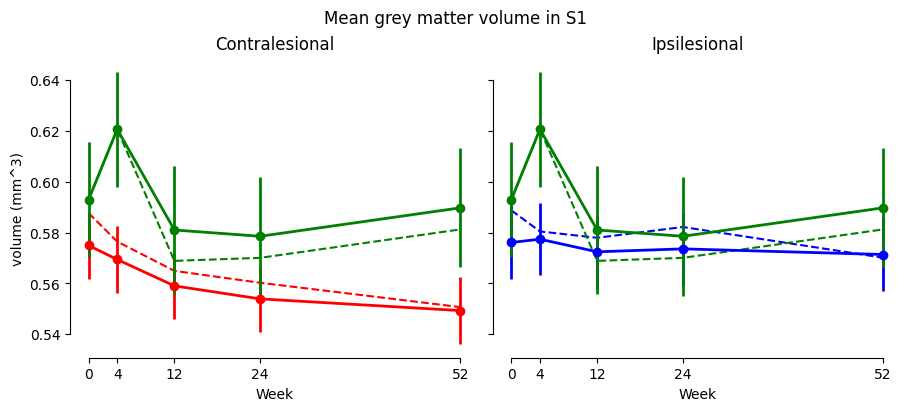

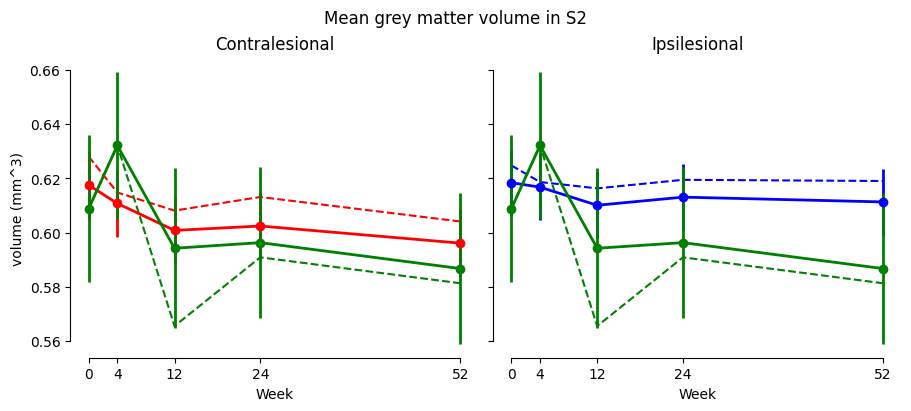

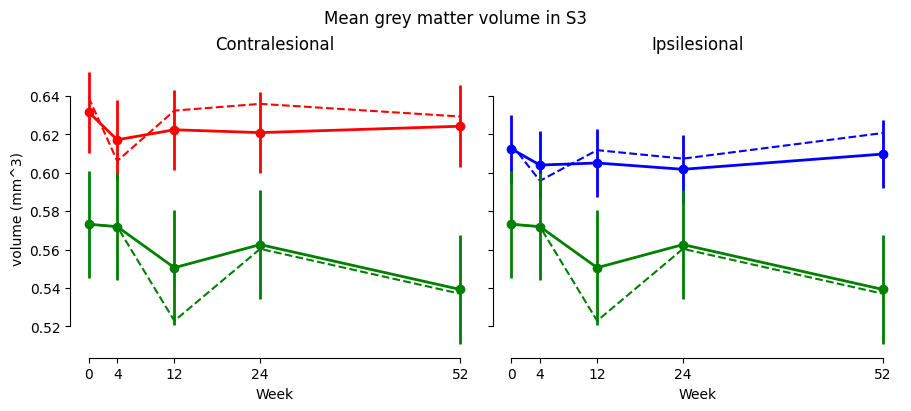

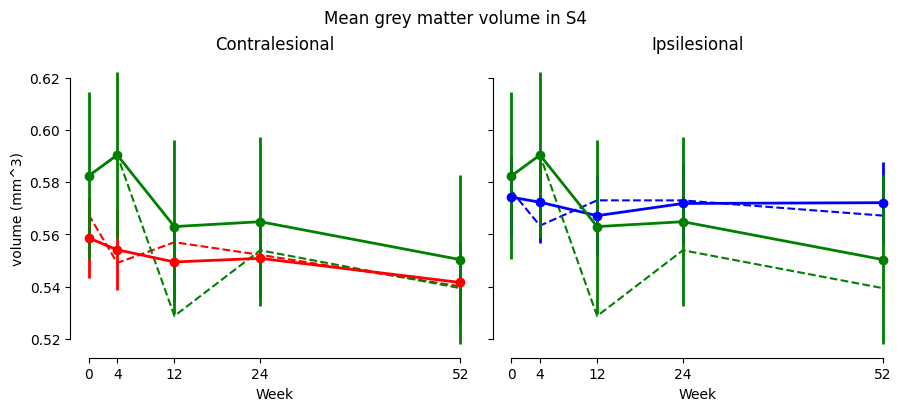

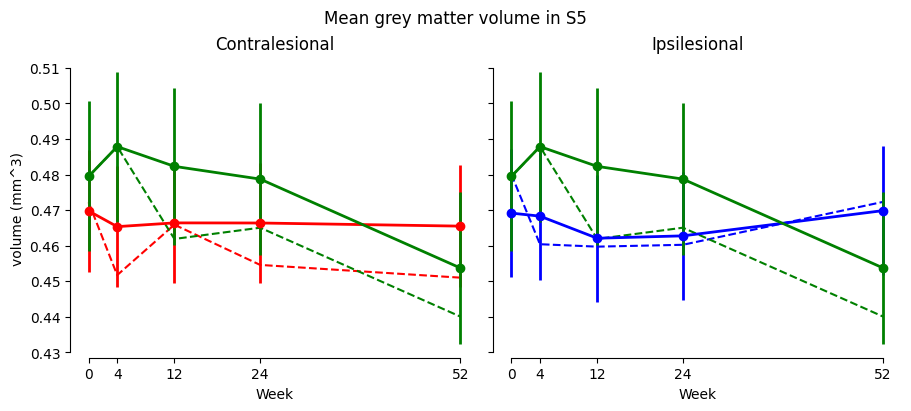

In [4]:
for r, roi in enumerate(rois):
    patients_lme_roi = patients_lme[patients_lme.regionname.str.contains(roi)].sort_values('Week')
    patients_actual_roi = patients_actual[patients_actual.regionname.str.contains(roi)].sort_values('Week')
    controls_lme_roi = controls_lme[controls_lme.regionname.str.contains(roi)].sort_values('Week')
    controls_actual_roi = controls_actual[controls_actual.regionname.str.contains(roi)].sort_values('Week')

    controls_lme_roi = controls_lme_roi.groupby(['Week']).agg({'beta': 'mean', 'se': 'mean'}).reset_index()
    controls_actual_roi = controls_actual_roi.groupby(['Week']).agg({'mean': 'mean'}).reset_index()

    fig, axs = plt.subplots(1, 2, figsize=(9,4), sharey = True, constrained_layout = True)

    for i, H in enumerate(gl.Hem):
        ax = axs[i]

        patients_lme_roi_h    = patients_lme_roi[patients_lme_roi.hemisphere == H].sort_values('Week')
        patients_actual_roi_h = patients_actual_roi[patients_actual_roi.hemisphere == H].sort_values('Week')


        ax.errorbar(x=patients_lme_roi_h['Week'], y=patients_lme_roi_h['beta'], yerr = patients_lme_roi_h['se'], fmt = '-o', color = colours[i+1], linewidth = 2, label = 'patients')
        ax.plot(patients_actual_roi_h['Week'], patients_actual_roi_h['mean'], color = colours[i+1], linestyle = '--')

        ax.errorbar(x=controls_lme_roi['Week'], y=controls_lme_roi['beta'], yerr = controls_lme_roi['se'], fmt = '-o', color = 'green', linewidth = 2, label = 'controls')
        ax.plot(controls_actual_roi['Week'], controls_actual_roi['mean'], color = 'green', linestyle = '--',)

        ax.set_title("Contralesional" if H == 'l' else "Ipsilesional")
        #ax.legend(loc = 'lower right', frameon = False) if i == 0 else None

    for i in range(2):
        axs[i].set_xticks(gl.weeks)
        axs[i].set_xlabel("Week")
        axs[i].set_title(gl.side[i])

    axs[0].set_ylabel('volume (mm^3)')

    fig.suptitle(f'Mean grey matter volume in {roi}')
    sns.despine(trim = True)

    fig.savefig(f'figure/lme_{roi}.pdf')

    plt.show()


In [5]:
obs_means = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')

obs_means['hemisphere'], obs_means['regionname'] = obs_means.regionname.str[2], obs_means.regionname.str[:2]
obs_means['group'] = np.where(obs_means.isPatient == 0, 'controls', np.where(obs_means.hemisphere == 'L', 'contralesional', 'ipsilesional'))
obs_means = obs_means.groupby(['subj_id', 'regionname', 'group', 'Week']).mean(numeric_only=True).reset_index()


In [6]:
obs_means = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')

obs_means['hemisphere'], obs_means['regionname'] = obs_means.regionname.str[2], obs_means.regionname.str[:2]
obs_means['group'] = np.where(obs_means.isPatient == 0, 'controls', np.where(obs_means.hemisphere == 'L', 'contralesional', 'ipsilesional'))
obs_means = obs_means.groupby(['subj_id', 'regionname', 'group', 'Week']).mean(numeric_only=True).reset_index()

for roi in rois:
    for week in gl.weeks:
        print(f'---t-tests for {roi} at week {week}---')
        t_val, p_val = stats.ttest_ind(obs_means[(obs_means.group=='ipsilesional') & (obs_means.regionname==roi) & (obs_means.Week == week)]['mean'], obs_means[(obs_means.group=='controls') & (obs_means.regionname==roi) & (obs_means.Week == week)]['mean'])
        print(f'**t-test for WM {roi}: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
        print('\n')

        t_val, p_val = stats.ttest_ind(obs_means[(obs_means.group=='contralesional') & (obs_means.regionname==roi) & (obs_means.Week == week)]['mean'], obs_means[(obs_means.group=='controls') & (obs_means.regionname==roi) & (obs_means.Week == week)]['mean'])
        print(f'**t-test for WM {roi}: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
        print('\n')

        t_val, p_val = stats.ttest_rel(obs_means[(obs_means.group=='contralesional') & (obs_means.regionname==roi) & (obs_means.Week == week)]['mean'], obs_means[(obs_means.group=='ipsilesional') & (obs_means.regionname==roi) & (obs_means.Week == week)]['mean'])
        print(f'**t-test for WM {roi}: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
        print('\n')



---t-tests for M1 at week 0---
**t-test for WM M1: lesion side in patients, controls** 
 t-value: 0.07084012414200526 	 p-value: 0.9439170765279357


**t-test for WM M1: non-lesion side in patients, controls** 
 t-value: -0.25600731969612933 	 p-value: 0.7994024280848373


**t-test for WM M1: within patients, left, right hemispheres** 
 t-value: -1.0275019193682025 	 p-value: 0.313301827032647


---t-tests for M1 at week 4---
**t-test for WM M1: lesion side in patients, controls** 
 t-value: 0.034121795924574455 	 p-value: 0.9729540724280243


**t-test for WM M1: non-lesion side in patients, controls** 
 t-value: -0.20071335059866247 	 p-value: 0.841965801254237


**t-test for WM M1: within patients, left, right hemispheres** 
 t-value: -0.8537021355441159 	 p-value: 0.4000355209341043


---t-tests for M1 at week 12---
**t-test for WM M1: lesion side in patients, controls** 
 t-value: -0.44876170736964266 	 p-value: 0.6560872419080306


**t-test for WM M1: non-lesion side in patients, 